In [2]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving newRBI_CBDC_SENTIMENT INDEX.xlsx to newRBI_CBDC_SENTIMENT INDEX.xlsx
User uploaded file "newRBI_CBDC_SENTIMENT INDEX.xlsx" with length 10269 bytes


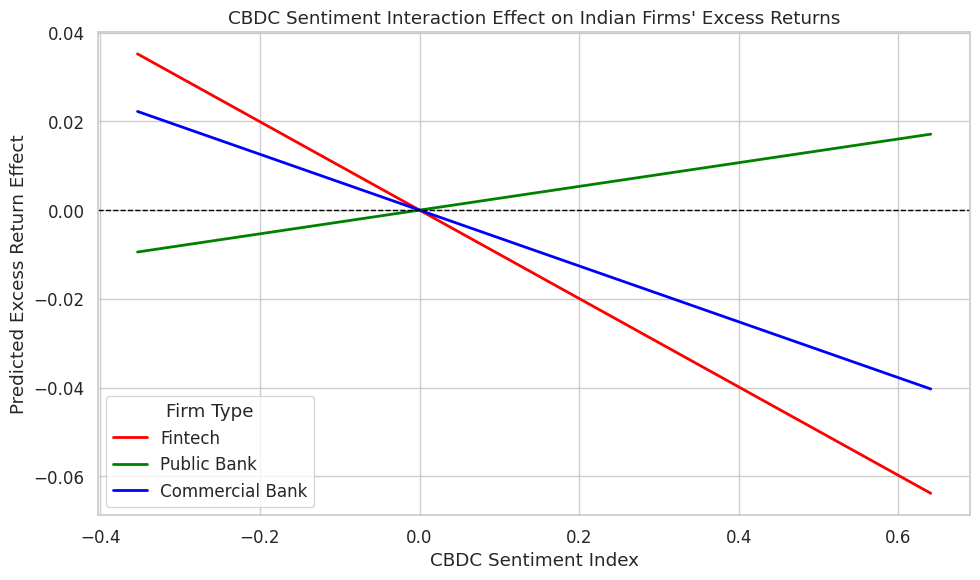

In [ ]:
# ======================================================
# Interaction Plot: CBDC Sentiment Effect by Firm Type
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Define a range of CBDC sentiment values
cbdc_range = np.linspace(panel['CBDC_SENTIMENT'].min(), panel['CBDC_SENTIMENT'].max(), 100)

# Extract coefficients from the interaction model
coefs = interaction_model.params

# Calculate predicted excess return effect for each firm type
effect_fintech = coefs['CBDC_SENTIMENT'] + coefs['CBDC_SENTIMENT:fintech']
effect_public = coefs['CBDC_SENTIMENT'] + coefs['CBDC_SENTIMENT:public_bank']
effect_commercial = coefs['CBDC_SENTIMENT'] + coefs['CBDC_SENTIMENT:commercial_bank']

# Predicted line (slope * CBDC sentiment)
y_fintech = effect_fintech * cbdc_range
y_public = effect_public * cbdc_range
y_commercial = effect_commercial * cbdc_range

# Plotting
plt.figure(figsize=(10,6))
plt.plot(cbdc_range, y_fintech, label='Fintech', color='red', linewidth=2)
plt.plot(cbdc_range, y_public, label='Public Bank', color='green', linewidth=2)
plt.plot(cbdc_range, y_commercial, label='Commercial Bank', color='blue', linewidth=2)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('CBDC Sentiment Index')
plt.ylabel('Predicted Excess Return Effect')
plt.title('CBDC Sentiment Interaction Effect on Indian Firms\' Excess Returns')
plt.legend(title='Firm Type')
plt.tight_layout()
plt.show()


In [ ]:
# ======================================================
# CBDC Sentiment Impact on Indian Firms' Stock Returns
# ------------------------------------------------------
# - Downloads firm prices from Yahoo Finance
# - Computes monthly log returns
# - Merges India 4-factor + CBDC sentiment data
# - Runs BIS-style regressions with interactions & firm fixed effects
# - Prints ONLY the 3 CBDC interaction coefficients + significance
# - Saves panel & a CSV with those 3 terms for both models
# ======================================================

# -----------------------
# 0) Imports & Settings
# -----------------------
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.formula.api as smf
import warnings
import time
import os

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

# -----------------------
# 1) Firm universe (Expanded)
# -----------------------
# Columns: firm_name, ticker, fintech, public_bank, commercial_bank
firms_info = [
    # Fintechs
    ("Paytm", "PAYTM.NS", 1, 0, 0),


    # Public Banks
    ("State Bank of India", "SBIN.NS", 0, 1, 0),
    ("Punjab National Bank", "PNB.NS", 0, 1, 0),
    ("Bank of Baroda", "BANKBARODA.NS", 0, 1, 0),
    ("Union Bank of India", "UNIONBANK.NS", 0, 1, 0),
    ("Canara Bank", "CANBK.NS", 0, 1, 0),

    # Commercial / Private Banks
    ("HDFC Bank", "HDFCBANK.NS", 0, 0, 1),
    ("ICICI Bank", "ICICIBANK.NS", 0, 0, 1),
    ("Axis Bank", "AXISBANK.NS", 0, 0, 1),
    ("Kotak Mahindra Bank", "KOTAKBANK.NS", 0, 0, 1),
    ("IDFC First Bank", "IDFCFIRSTB.NS", 0, 0, 1),
    ("Yes Bank", "YESBANK.NS", 0, 0, 1),
]
firms = pd.DataFrame(firms_info, columns=["firm_name", "ticker", "fintech", "public_bank", "commercial_bank"])

# -----------------------
# 2) Date range
# -----------------------
start = "2022-12-01"
end   = "2025-03-30"

# -----------------------
# 3) Helpers
# -----------------------
def pick_close_column(df):
    """Prefer 'Adj Close' if available, otherwise any column containing 'Close'."""
    # Flatten MultiIndex if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ['_'.join([c for c in tup if c]).strip() for tup in df.columns.values]
    cols = list(df.columns)
    for c in cols:
        if "Adj Close" in c or "Adj_Close" in c or "AdjClose" in c:
            return c
    for c in cols:
        if "Close" in c:
            return c
    return None

def download_monthly_returns(ticker, start, end, pause=0.6):
    """Download daily data via yfinance, get monthly last, compute log returns."""
    try:
        data = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=False)
        time.sleep(pause)  # polite pause for rate limits
    except Exception as e:
        print(f"❌ Download failed for {ticker}: {e}")
        return None

    if data is None or data.empty:
        print(f"⚠️ No data for {ticker}")
        return None

    price_col = pick_close_column(data)
    if price_col is None:
        print(f"⚠️ No suitable Close column for {ticker}")
        return None

    monthly = data[[price_col]].resample("M").last().copy()
    monthly.rename(columns={price_col: "Close"}, inplace=True)
    monthly["ret"] = np.log(monthly["Close"] / monthly["Close"].shift(1))
    monthly["month"] = monthly.index
    monthly["firm_id"] = ticker
    out = monthly[["firm_id", "month", "ret"]].dropna()
    if out.empty:
        print(f"⚠️ No return observations after resampling for {ticker}")
        return None
    return out

def add_sig_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""

# -----------------------
# 4) Download all firms
# -----------------------
all_prices, skipped = [], []
for _, row in firms.iterrows():
    tkr = row["ticker"]
    r = download_monthly_returns(tkr, start, end, pause=0.6)
    if r is None:
        skipped.append(tkr)
    else:
        all_prices.append(r)

if len(all_prices) == 0:
    raise RuntimeError("No price data downloaded. Check tickers or network settings.")

returns = pd.concat(all_prices, ignore_index=True)
print(f"✅ Downloaded monthly prices for {returns['firm_id'].nunique()} firms, rows: {len(returns)}")
if skipped:
    print("⚠️ Skipped (no/insufficient data):", skipped)
print(returns.head())

# -----------------------
# 5) Load factors (CSV) & CBDC sentiment (XLSX)
# -----------------------
# --- Factors
factors_path = "Indian_Fama_French_Momentum_Factors_MONTHLY.csv"
if not os.path.exists(factors_path):
    raise FileNotFoundError(f"Missing: {factors_path}")

factors = pd.read_csv(factors_path)
factors.columns = [c.strip().upper() for c in factors.columns]

date_candidates = [c for c in factors.columns if 'DATE' in c or 'MONTH' in c]
if not date_candidates:
    raise ValueError("Could not identify date column in factors file.")
f_date = date_candidates[0]

rename_map = {}
if 'MF' in factors.columns: rename_map['MF'] = 'MKT_RF'
if 'WML' in factors.columns: rename_map['WML'] = 'MOM'
if 'RF' in factors.columns: rename_map['RF'] = 'RF'
factors = factors.rename(columns=rename_map)

factors = factors.rename(columns={f_date: 'month'})
factors['month'] = pd.to_datetime(factors['month'], dayfirst=True, errors='coerce')
factors = factors.dropna(subset=['month'])
factors = factors.set_index('month').resample('M').last().reset_index()

needed = ['MKT_RF', 'SMB', 'HML', 'MOM', 'RF']
for col in needed:
    if col not in factors.columns:
        raise ValueError(f"Missing factor column: {col}")

# --- Sentiment
sent_path = "newRBI_CBDC_SENTIMENT INDEX.xlsx"
if not os.path.exists(sent_path):
    raise FileNotFoundError(f"Missing: {sent_path}")

sentiment = pd.read_excel(sent_path)
sentiment.columns = [c.strip().upper() for c in sentiment.columns]

s_date_candidates = [c for c in sentiment.columns if 'DATE' in c or 'MONTH' in c]
if not s_date_candidates:
    raise ValueError("Could not identify date column in sentiment file.")
s_date = s_date_candidates[0]

s_cols = [c for c in sentiment.columns if 'CBDC' in c and 'SENTIMENT' in c]
if not s_cols:
    raise ValueError("Could not identify CBDC sentiment column in sentiment file.")
s_col = s_cols[0]

sentiment = sentiment.rename(columns={s_date: 'month', s_col: 'CBDC_SENTIMENT'})
sentiment['month'] = pd.to_datetime(sentiment['month'], dayfirst=True, errors='coerce')
sentiment = sentiment.dropna(subset=['month'])
sentiment = sentiment.set_index('month').resample('M').last().reset_index()

# -----------------------
# 6) Merge into panel
# -----------------------
panel = (
    returns
    .merge(factors[['month'] + needed], on='month', how='left')
    .merge(sentiment[['month', 'CBDC_SENTIMENT']], on='month', how='left')
    .merge(firms, left_on='firm_id', right_on='ticker', how='left')
    .sort_values(['firm_id', 'month'])
    .reset_index(drop=True)
)

# Drop rows with missing regressors or dummies
reg_cols = ['ret', 'MKT_RF', 'SMB', 'HML', 'MOM', 'CBDC_SENTIMENT', 'fintech', 'public_bank', 'commercial_bank', 'firm_id']
panel_clean = panel.dropna(subset=reg_cols).copy()

print("✅ Panel data created. Shape:", panel_clean.shape)
print(panel_clean.head())

# Save panel
panel_clean.to_csv("india_cbdc_panel_yahoo.csv", index=False)
print("💾 Saved final panel: india_cbdc_panel_yahoo.csv")

# -----------------------
# 7) Regressions with clustered SEs (clustered by firm_id)
# -----------------------
# Baseline
baseline = smf.ols(
    'ret ~ MKT_RF + SMB + HML + MOM + CBDC_SENTIMENT',
    data=panel_clean
).fit(cov_type='cluster', cov_kwds={'groups': panel_clean['firm_id']})

print("\n================== Baseline Model ==================")
print(baseline.summary())

# Interaction
interaction_model = smf.ols(
    'ret ~ MKT_RF + SMB + HML + MOM + CBDC_SENTIMENT'
    ' + CBDC_SENTIMENT:fintech + CBDC_SENTIMENT:public_bank + CBDC_SENTIMENT:commercial_bank',
    data=panel_clean
).fit(cov_type='cluster', cov_kwds={'groups': panel_clean['firm_id']})

print("\n================== Interaction Model ==================")
print(interaction_model.summary())

# Firm fixed effects (via firm dummies)
fe_model = smf.ols(
    'ret ~ MKT_RF + SMB + HML + MOM + CBDC_SENTIMENT'
    ' + CBDC_SENTIMENT:fintech + CBDC_SENTIMENT:public_bank + CBDC_SENTIMENT:commercial_bank'
    ' + C(firm_id)',
    data=panel_clean
).fit(cov_type='cluster', cov_kwds={'groups': panel_clean['firm_id']})

print("\n================== Firm Fixed-Effects Model ==================")
print(fe_model.summary())

# -----------------------
# 8) PRINT & SAVE ONLY THE 3 CBDC INTERACTION COEFFICIENTS + SIGNIFICANCE
# -----------------------
def extract_cbdc_interactions(model, model_name):
    """Extract the 3 CBDC interaction coefficients with p-values and significance."""
    terms = [
        "CBDC_SENTIMENT:fintech",
        "CBDC_SENTIMENT:public_bank",
        "CBDC_SENTIMENT:commercial_bank"
    ]
    rows = []
    print(f"\n================== {model_name}: CBDC Interaction Effects ==================")
    for term in terms:
        if term in model.params.index:
            coef = float(model.params[term])
            pval = float(model.pvalues[term])
            sig = add_sig_stars(pval)
            rows.append({"model": model_name, "term": term, "coef": coef, "pval": pval, "sig": sig})
            print(f"{term:<35} Coef: {coef:>8.4f}   p-value: {pval:>6.4f}   Significance: {sig}")
        else:
            rows.append({"model": model_name, "term": term, "coef": np.nan, "pval": np.nan, "sig": ""})
            print(f"{term:<35} Not found in model")
    return pd.DataFrame(rows)

int_df = extract_cbdc_interactions(interaction_model, "Interaction Model")
fe_df  = extract_cbdc_interactions(fe_model, "Firm Fixed-Effects Model")

out_df = pd.concat([int_df, fe_df], ignore_index=True)
out_df.to_csv("cbdc_interaction_summary.csv", index=False)
print("\n💾 Saved CBDC interaction coefficients: cbdc_interaction_summary.csv")

print("\n✅ Done.")
print("⭐ Significance: *** p<0.01, ** p<0.05, * p<0.10")
if skipped:
    print("Note: Some tickers were skipped due to missing or insufficient data:", skipped)


✅ Downloaded monthly prices for 12 firms, rows: 324
    firm_id      month       ret
0  PAYTM.NS 2023-01-31 -0.000188
1  PAYTM.NS 2023-02-28  0.117762
2  PAYTM.NS 2023-03-31  0.064120
3  PAYTM.NS 2023-04-30  0.026040
4  PAYTM.NS 2023-05-31  0.064792
✅ Panel data created. Shape: (324, 14)
       firm_id      month       ret    MKT_RF       SMB       HML       MOM        RF  CBDC_SENTIMENT  firm_name       ticker  fintech  public_bank  \
0  AXISBANK.NS 2023-01-31 -0.068878 -4.537255  0.356154  3.752588 -3.129454  0.544402        0.388485  Axis Bank  AXISBANK.NS        0            0   
1  AXISBANK.NS 2023-02-28 -0.032060 -5.476681 -2.402524  0.287314 -1.861804  0.497016       -0.353333  Axis Bank  AXISBANK.NS        0            0   
2  AXISBANK.NS 2023-03-31  0.016916  0.303865 -2.432807  0.867471  1.857683  0.565370        0.309524  Axis Bank  AXISBANK.NS        0            0   
3  AXISBANK.NS 2023-04-30  0.001746  4.085623  6.259383  2.891240 -3.800592  0.505361        0.200000  Axis

In [ ]:
# ======================================================
# CBDC Sentiment Impact on Indian Firms' Stock Returns
# ------------------------------------------------------
# - Downloads firm prices from Yahoo Finance
# - Computes monthly log returns
# - Merges India 4-factor + CBDC sentiment data
# - Runs BIS-style regressions with interactions & firm fixed effects
# - Prints & saves only CBDC interaction coefficients with significance
# ======================================================

import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.formula.api as smf
import warnings
import time
import os

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

# ======================================================
# 1️⃣ Define firm universe (Fintech + Banks + IT firms)
# ======================================================
firms_info = [
    # ----------------- Fintechs -----------------
    ("Paytm", "PAYTM.NS", 1, 0, 0, 0),

    # ----------------- Public Banks -----------------
    ("State Bank of India", "SBIN.NS", 0, 1, 0, 0),
    ("Punjab National Bank", "PNB.NS", 0, 1, 0, 0),
    ("Bank of Baroda", "BANKBARODA.NS", 0, 1, 0, 0),
    ("Union Bank of India", "UNIONBANK.NS", 0, 1, 0, 0),
    ("Canara Bank", "CANBK.NS", 0, 1, 0, 0),

    # ----------------- Private / Commercial Banks -----------------
    ("HDFC Bank", "HDFCBANK.NS", 0, 0, 1, 0),
    ("ICICI Bank", "ICICIBANK.NS", 0, 0, 1, 0),
    ("Axis Bank", "AXISBANK.NS", 0, 0, 1, 0),
    ("Kotak Mahindra Bank", "KOTAKBANK.NS", 0, 0, 1, 0),
    ("IDFC First Bank", "IDFCFIRSTB.NS", 0, 0, 1, 0),
    ("Yes Bank", "YESBANK.NS", 0, 0, 1, 0),

    # ----------------- IT Companies -----------------
    ("Infosys", "INFY.NS", 0, 0, 0, 1),
    ("TCS", "TCS.NS", 0, 0, 0, 1),
    ("Wipro", "WIPRO.NS", 0, 0, 0, 1),
    ("Tech Mahindra", "TECHM.NS", 0, 0, 0, 1),
    ("HCL Technologies", "HCLTECH.NS", 0, 0, 0, 1)
]

firms = pd.DataFrame(firms_info, columns=["firm_name", "ticker", "fintech", "public_bank", "commercial_bank", "it_company"])

# ======================================================
# 2️⃣ Date Range
# ======================================================
start = "2022-12-01"
end   = "2025-03-30"

# ======================================================
# 3️⃣ Helper Functions
# ======================================================
def pick_close_column(df):
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ['_'.join([c for c in tup if c]).strip() for tup in df.columns.values]
    cols = list(df.columns)
    for c in cols:
        if "Adj Close" in c or "Adj_Close" in c or "AdjClose" in c:
            return c
    for c in cols:
        if "Close" in c:
            return c
    return None

def download_monthly_returns(ticker, start, end, pause=0.6):
    """Download daily prices, convert to monthly log returns."""
    try:
        data = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=False)
        time.sleep(pause)
    except Exception as e:
        print(f"❌ Download failed for {ticker}: {e}")
        return None
    if data is None or data.empty:
        print(f"⚠️ No data for {ticker}")
        return None
    price_col = pick_close_column(data)
    if price_col is None:
        print(f"⚠️ No suitable Close column for {ticker}")
        return None
    monthly = data[[price_col]].resample("M").last().copy()
    monthly.rename(columns={price_col: "Close"}, inplace=True)
    monthly["ret"] = np.log(monthly["Close"] / monthly["Close"].shift(1))
    monthly["month"] = monthly.index
    monthly["firm_id"] = ticker
    return monthly[["firm_id", "month", "ret"]].dropna()

def add_sig_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""

# ======================================================
# 4️⃣ Download Price Data
# ======================================================
all_prices, skipped = [], []
for _, row in firms.iterrows():
    data = download_monthly_returns(row["ticker"], start, end)
    if data is not None:
        all_prices.append(data)
    else:
        skipped.append(row["ticker"])

returns = pd.concat(all_prices, ignore_index=True)
print(f"✅ Downloaded monthly prices for {returns['firm_id'].nunique()} firms, rows: {len(returns)}")
if skipped:
    print("⚠️ Skipped (no/insufficient data):", skipped)

# ======================================================
# 5️⃣ Load Factors & CBDC Sentiment
# ======================================================
# --- Factors
factors = pd.read_csv("Indian_Fama_French_Momentum_Factors_MONTHLY.csv")
factors.columns = [c.strip().upper() for c in factors.columns]
date_col = [c for c in factors.columns if 'DATE' in c or 'MONTH' in c][0]
factors.rename(columns={date_col: 'month'}, inplace=True)
factors.rename(columns={'MF':'MKT_RF','WML':'MOM','RF':'RF'}, inplace=True)
factors['month'] = pd.to_datetime(factors['month'], dayfirst=True)
factors = factors.set_index('month').resample('M').last().reset_index()

# --- CBDC Sentiment
sentiment = pd.read_excel("newRBI_CBDC_SENTIMENT INDEX.xlsx")
sentiment.columns = [c.strip().upper() for c in sentiment.columns]
date_col = [c for c in sentiment.columns if 'DATE' in c or 'MONTH' in c][0]
sent_col = [c for c in sentiment.columns if 'CBDC' in c and 'SENTIMENT' in c][0]
sentiment.rename(columns={date_col:'month', sent_col:'CBDC_SENTIMENT'}, inplace=True)
sentiment['month'] = pd.to_datetime(sentiment['month'], dayfirst=True)
sentiment = sentiment.set_index('month').resample('M').last().reset_index()

# ======================================================
# 6️⃣ Merge Panel
# ======================================================
panel = (
    returns
    .merge(factors[['month','MKT_RF','SMB','HML','MOM','RF']], on='month', how='left')
    .merge(sentiment[['month','CBDC_SENTIMENT']], on='month', how='left')
    .merge(firms, left_on='firm_id', right_on='ticker', how='left')
)
panel = panel.dropna(subset=['ret','CBDC_SENTIMENT']).sort_values(['firm_id','month']).reset_index(drop=True)

panel.to_csv("india_cbdc_panel_yahoo.csv", index=False)
print("✅ Panel created. Shape:", panel.shape)
print("💾 Saved: india_cbdc_panel_yahoo.csv")

# ======================================================
# 7️⃣ Regressions (Clustered SE by firm)
# ======================================================
# Baseline
baseline = smf.ols(
    'ret ~ MKT_RF + SMB + HML + MOM + CBDC_SENTIMENT',
    data=panel
).fit(cov_type='cluster', cov_kwds={'groups': panel['firm_id']})

# Interaction
interaction_model = smf.ols(
    'ret ~ MKT_RF + SMB + HML + MOM + CBDC_SENTIMENT'
    ' + CBDC_SENTIMENT:fintech + CBDC_SENTIMENT:public_bank'
    ' + CBDC_SENTIMENT:commercial_bank + CBDC_SENTIMENT:it_company',
    data=panel
).fit(cov_type='cluster', cov_kwds={'groups': panel['firm_id']})

# Fixed Effects
fe_model = smf.ols(
    'ret ~ MKT_RF + SMB + HML + MOM + CBDC_SENTIMENT'
    ' + CBDC_SENTIMENT:fintech + CBDC_SENTIMENT:public_bank'
    ' + CBDC_SENTIMENT:commercial_bank + CBDC_SENTIMENT:it_company + C(firm_id)',
    data=panel
).fit(cov_type='cluster', cov_kwds={'groups': panel['firm_id']})

# ======================================================
# 8️⃣ Extract & Save Only CBDC Interaction Coefficients
# ======================================================
def extract_cbdc_interactions(model, model_name):
    terms = [
        "CBDC_SENTIMENT:fintech",
        "CBDC_SENTIMENT:public_bank",
        "CBDC_SENTIMENT:commercial_bank",
        "CBDC_SENTIMENT:it_company"
    ]
    rows = []
    print(f"\n================== {model_name}: CBDC Interaction Effects ==================")
    for term in terms:
        if term in model.params.index:
            coef = float(model.params[term])
            pval = float(model.pvalues[term])
            sig = add_sig_stars(pval)
            rows.append({"model": model_name, "term": term, "coef": coef, "pval": pval, "sig": sig})
            print(f"{term:<35} Coef: {coef:>8.4f}   p-value: {pval:>6.4f}   Significance: {sig}")
        else:
            rows.append({"model": model_name, "term": term, "coef": np.nan, "pval": np.nan, "sig": ""})
            print(f"{term:<35} Not found in model")
    return pd.DataFrame(rows)

int_df = extract_cbdc_interactions(interaction_model, "Interaction Model")
fe_df  = extract_cbdc_interactions(fe_model, "Firm Fixed-Effects Model")

out_df = pd.concat([int_df, fe_df], ignore_index=True)
out_df.to_csv("cbdc_interaction_summary_expanded.csv", index=False)
print("\n💾 Saved CBDC interaction coefficients: cbdc_interaction_summary_expanded.csv")

print("\n✅ Done.")
print("⭐ Significance: *** p<0.01, ** p<0.05, * p<0.10")
if skipped:
    print("Note: Some tickers were skipped due to missing or insufficient data:", skipped)

✅ Downloaded monthly prices for 17 firms, rows: 459
✅ Panel created. Shape: (459, 15)
💾 Saved: india_cbdc_panel_yahoo.csv

================== Interaction Model: CBDC Interaction Effects ==================
CBDC_SENTIMENT:fintech              Coef:  -0.0672   p-value: 0.0000   Significance: ***
CBDC_SENTIMENT:public_bank          Coef:   0.0526   p-value: 0.0000   Significance: ***
CBDC_SENTIMENT:commercial_bank      Coef:  -0.0290   p-value: 0.0004   Significance: ***
CBDC_SENTIMENT:it_company           Coef:   0.0246   p-value: 0.0000   Significance: ***

================== Firm Fixed-Effects Model: CBDC Interaction Effects ==================
CBDC_SENTIMENT:fintech              Coef:  -0.1188   p-value: 0.0000   Significance: ***
CBDC_SENTIMENT:public_bank          Coef:   0.0726   p-value: 0.0000   Significance: ***
CBDC_SENTIMENT:commercial_bank      Coef:  -0.0220   p-value: 0.0365   Significance: **
CBDC_SENTIMENT:it_company           Coef:   0.0394   p-value: 0.0000   Significance

In [13]:
# final_interaction_only_regressions.py
import os
import sys
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import t

# -----------------------
# User config
# -----------------------
PANEL_PATH = "/content/panel_yahoo_final.csv"   # corrected path
OUTPUT_SUMMARY = "cbdc_interaction_only_summary.csv"
CLUSTER_COL_PREFERRED = ["firm_id", "firm_name", "ticker"]  # candidate clustering columns

# -----------------------
# Helper utilities
# -----------------------
def find_col(df, candidates):
    """Return first matching column name from candidates (case-insensitive)."""
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

def sig_stars(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""

# -----------------------
# Load panel
# -----------------------
if not os.path.exists(PANEL_PATH):
    raise FileNotFoundError(f"Panel file not found at: {PANEL_PATH}")

panel = pd.read_csv(PANEL_PATH, parse_dates=True)
print("Loaded panel:", PANEL_PATH)
print("Panel shape:", panel.shape)
print("Available columns:", list(panel.columns))

# -----------------------
# Identify required columns (robust to naming)
# -----------------------
ret_col = find_col(panel, ["ret", "return", "returns", "monthly_return", "stock_return"])
sent_col = find_col(panel, ["cbdc_sentiment", "sentimental index", "sentiment", "sentimental_index", "sentiment_index"])
# industry dummies - allow both lower/upper variants
fintech_col = find_col(panel, ["fintech", "FINTECH"])
public_col  = find_col(panel, ["public_bank", "PUBLIC BANK", "public bank", "public_bank"])
commercial_col = find_col(panel, ["commercial_bank", "commercial bank", "COMMERCIAL BANK", "private_bank"])
it_col = find_col(panel, ["it_company", "it", "IT", "it_company"])

# clustering column
cluster_col = None
for cand in CLUSTER_COL_PREFERRED:
    if cand in panel.columns:
        cluster_col = cand
        break
if cluster_col is None:
    # fallback: use firm_name if present, else firm_id, else ticker, else raise
    cluster_col = find_col(panel, ["firm_name", "firm_id", "ticker"])
if cluster_col is None:
    raise KeyError("Cannot find a suitable firm identifier column for clustering. Add 'firm_id', 'ticker' or 'firm_name' to the panel.")

# Check that all required vars present
missing = []
for name, col in [("return", ret_col), ("sentiment", sent_col),
                  ("fintech dummy", fintech_col), ("public bank dummy", public_col),
                  ("commercial bank dummy", commercial_col), ("it dummy", it_col),
                  ("cluster id", cluster_col)]:
    if col is None:
        missing.append(name)
if missing:
    raise KeyError(f"Missing required columns in panel for: {missing}. Please ensure your CSV contains these variables (or rename them).")

print(f"Using columns -> ret: {ret_col}, sentiment: {sent_col}, fintech: {fintech_col}, public: {public_col}, commercial: {commercial_col}, it: {it_col}, cluster: {cluster_col}")

# Normalize column names to simple names used in formulas
panel = panel.rename(columns={
    ret_col: "ret",
    sent_col: "CBDC_SENTIMENT",
    fintech_col: "fintech",
    public_col: "public_bank",
    commercial_col: "commercial_bank",
    it_col: "it_company",
    cluster_col: "cluster_id"
})

# Explicitly rename 'MKT-RF' to 'MKT_RF' for formula compatibility
if 'MKT-RF' in panel.columns:
    panel.rename(columns={'MKT-RF': 'MKT_RF'}, inplace=True)

# Ensure numeric types
panel["ret"] = pd.to_numeric(panel["ret"], errors="coerce")
panel["CBDC_SENTIMENT"] = pd.to_numeric(panel["CBDC_SENTIMENT"], errors="coerce")
for c in ["fintech", "public_bank", "commercial_bank", "it_company"]:
    panel[c] = pd.to_numeric(panel[c].fillna(0), errors="coerce").astype(int)

# Drop rows missing the essentials
panel = panel.dropna(subset=["ret", "CBDC_SENTIMENT"])
panel = panel.reset_index(drop=True)
print("Panel after dropna shape:", panel.shape)

# -----------------------
# Define formulas (interaction-only: no main CBDC_SENTIMENT term)
# -----------------------
# Use 'MKT_RF' (with underscore) since it's renamed above
base_factors = "MKT_RF + SMB + HML + MOM"
# if your factor columns have different names, rename them in the panel before running
# The formula below intentionally excludes a standalone CBDC_SENTIMENT term
interaction_formula = (
    'ret ~ ' + base_factors +
    ' + CBDC_SENTIMENT:fintech' +
    ' + CBDC_SENTIMENT:public_bank' +
    ' + CBDC_SENTIMENT:commercial_bank' +
    ' + CBDC_SENTIMENT:it_company'
)

fe_formula = interaction_formula + ' + C(cluster_id)'

print("\nInteraction-only formula:\n", interaction_formula)
print("\nFixed-effects formula:\n", fe_formula)

# -----------------------
# Run regressions
# -----------------------
print("\nFitting interaction model (no firm FE)...")
interaction_model = smf.ols(interaction_formula, data=panel).fit(cov_type='cluster', cov_kwds={'groups': panel['cluster_id']})
print("Done.")

print("\nFitting firm fixed-effects model (C(cluster_id))...")
fe_model = smf.ols(fe_formula, data=panel).fit(cov_type='cluster', cov_kwds={'groups': panel['cluster_id']})
print("Done.")

# -----------------------
# Extract interaction coefficients (deltas) and p-values
# -----------------------
terms = [
    "CBDC_SENTIMENT:fintech",
    "CBDC_SENTIMENT:public_bank",
    "CBDC_SENTIMENT:commercial_bank",
    "CBDC_SENTIMENT:it_company"
]

rows = []
print("\n================== Interaction-Only Results (FE model) ==================")
for term in terms:
    if term in fe_model.params.index:
        coef = float(fe_model.params[term])
        pval = float(fe_model.pvalues[term])
        se = float(fe_model.bse[term])
        stars = sig_stars(pval)
        rows.append({
            "term": term,
            "coef": coef,
            "std_err": se,
            "p_value": pval,
            "significance": stars
        })
        print(f"{term:<35} Coef: {coef:>8.4f}   SE: {se:>8.4f}   p-value: {pval:>8.4f}   {stars}")
    else:
        rows.append({"term": term, "coef": np.nan, "std_err": np.nan, "p_value": np.nan, "significance": ""})
        print(f"{term:<35} NOT FOUND in model")

# Save summary
df_out = pd.DataFrame(rows)
df_out.to_csv(OUTPUT_SUMMARY, index=False)
print(f"\nSaved interaction-only summary to {OUTPUT_SUMMARY}")

# -----------------------
# Print short model summaries (optional)
# -----------------------
print("\n--- Interaction model summary (top lines) ---")
print(interaction_model.summary().tables[0])
print("\n--- Fixed-effects model summary (top lines) ---")
print(fe_model.summary().tables[0])

# End
print("\nAll done.")


Loaded panel: /content/panel_yahoo_final.csv
Panel shape: (459, 14)
Available columns: ['firm_name', 'stock_month_end', 'month', 'MKT-RF', 'SMB', 'HML', 'MOM', 'FINTECH', 'COMMERCIAL BANK', 'PUBLIC BANK', 'IT', 'sentimental index', 'ret', 'n_trading_days']
Using columns -> ret: ret, sentiment: sentimental index, fintech: FINTECH, public: PUBLIC BANK, commercial: COMMERCIAL BANK, it: IT, cluster: firm_name
Panel after dropna shape: (442, 14)

Interaction-only formula:
 ret ~ MKT_RF + SMB + HML + MOM + CBDC_SENTIMENT:fintech + CBDC_SENTIMENT:public_bank + CBDC_SENTIMENT:commercial_bank + CBDC_SENTIMENT:it_company

Fixed-effects formula:
 ret ~ MKT_RF + SMB + HML + MOM + CBDC_SENTIMENT:fintech + CBDC_SENTIMENT:public_bank + CBDC_SENTIMENT:commercial_bank + CBDC_SENTIMENT:it_company + C(cluster_id)

Fitting interaction model (no firm FE)...
Done.

Fitting firm fixed-effects model (C(cluster_id))...
Done.

================== Interaction-Only Results (FE model) ==================
CBDC_SENTIM

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 7
  warnings.warn('covariance of constraints does not have full '


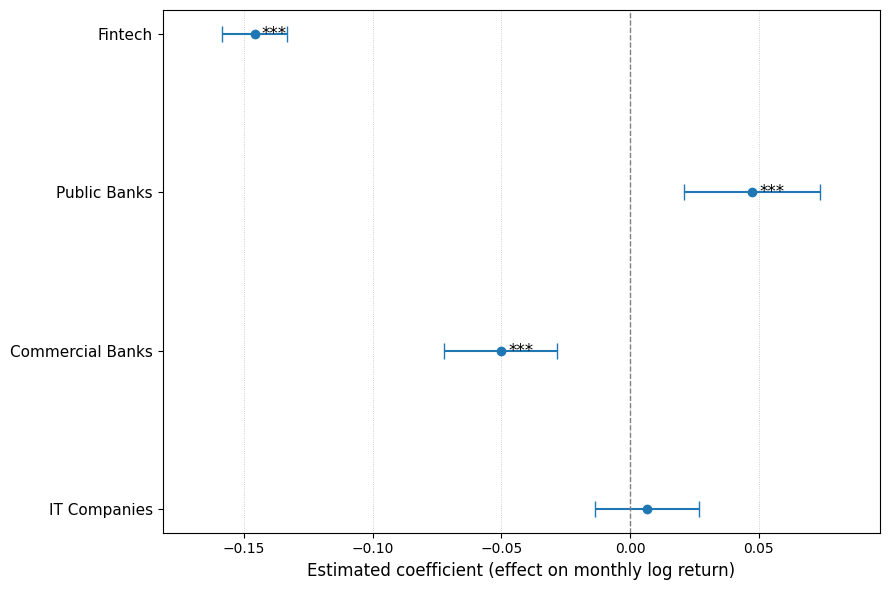

Saved plot to cbdc_interaction_coeffs_plot.png


In [24]:
# plot_interaction_coeffs.py
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Path to summary CSV (adjust if needed). The script will try both locations.
paths = [
    "/mnt/data/cbdc_interaction_only_summary.csv",
    "cbdc_interaction_only_summary.csv"
]
csv_path = next((p for p in paths if os.path.exists(p)), paths[1])

# --- Load results CSV which should have columns: term, coef, std_err, p_value, significance
df = pd.read_csv(csv_path)

# --- Map the term names from the CSV to friendly labels in plotting order
label_map = {
    "CBDC_SENTIMENT:fintech": "Fintech",
    "CBDC_SENTIMENT:public_bank": "Public Banks",
    "CBDC_SENTIMENT:commercial_bank": "Commercial Banks",
    "CBDC_SENTIMENT:it_company": "IT Companies"
}

# Filter & order
terms_order = [
    "CBDC_SENTIMENT:fintech",
    "CBDC_SENTIMENT:public_bank",
    "CBDC_SENTIMENT:commercial_bank",
    "CBDC_SENTIMENT:it_company"
]
df = df.set_index("term").reindex(terms_order).reset_index()

# If any std_err column is named differently, try to detect common variants
if "std_err" not in df.columns:
    for alt in ["std_error", "std_err", "se", "std"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "std_err"})
            break

# Extract plotting arrays
labels = [label_map.get(t, t) for t in df["term"].tolist()]
coefs = df["coef"].astype(float).values
ses = df["std_err"].astype(float).values

# 95% CI
ci95 = 1.96 * ses
lower = coefs - ci95
upper = coefs + ci95

# --- Plotting
plt.style.use('default')  # do not force seaborn styles
fig, ax = plt.subplots(figsize=(9,6))

y_pos = np.arange(len(labels))

# horizontal errorbar plot (points at coef, errorbars for CI)
ax.errorbar(coefs, y_pos, xerr=ci95, fmt='o', capsize=6, markersize=6, linestyle='None')

# Add vertical zero line
ax.axvline(0, color='gray', linestyle='--', linewidth=1)

# Y axis
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.invert_yaxis()  # optional: invert so first label on top

# x-limits: add margin
xmin = min(lower.min(), coefs.min()) - abs(0.1 * (upper.max() - lower.min()))
xmax = max(upper.max(), coefs.max()) + abs(0.1 * (upper.max() - lower.min()))
ax.set_xlim(xmin, xmax)

# Labels and grid
ax.set_xlabel("Estimated coefficient (effect on monthly log return)", fontsize=12)
ax.grid(axis='x', linestyle=':', linewidth=0.6, alpha=0.8)

# Annotate significance stars next to points (if available)
if "significance" in df.columns:
    for i, sig in enumerate(df["significance"].fillna("")):
        if sig:
            ax.text(coefs[i] + (xmax-xmin)*0.01, y_pos[i], sig, va='center', fontsize=12)

plt.tight_layout()
out_file = "cbdc_interaction_coeffs_plot.png"
plt.savefig(out_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to {out_file}")S

/tmp/ipython-input-219120786.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 0.94])  # leave space for suptitle and inset


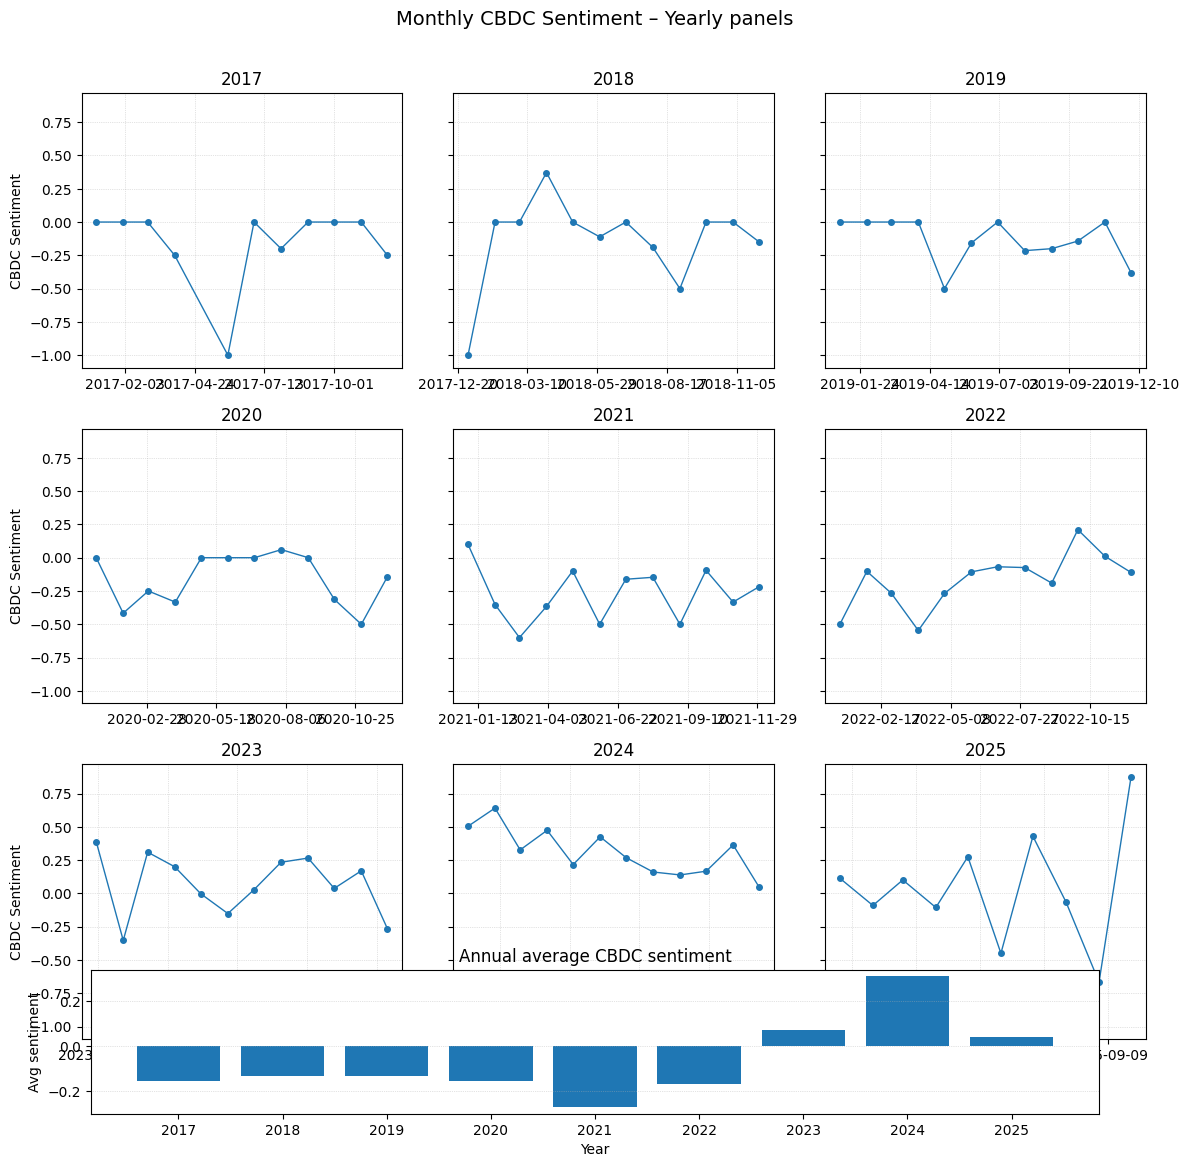

Saved figure to: cbdc_sentiment_by_year.png


In [20]:
# plot_cbdc_sentiment_by_year.py
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ---- user file (from your workspace) ----
SENTIMENT_XLSX = "newRBI_CBDC_SENTIMENT INDEX.xlsx"

# ---- read file and detect columns ----
df = pd.read_excel(SENTIMENT_XLSX)
df.columns = [c.strip() for c in df.columns]

# find date and sentiment columns (robust)
date_col = None
sent_col = None
for c in df.columns:
    lc = c.lower()
    if ('date' in lc) or ('month' in lc):
        date_col = c
    if ('cbdc' in lc and 'sent' in lc) or ('sent' in lc and 'cbdc' not in lc):
        # prefer explicit cbdc sentiment column; otherwise first sentiment-like
        if sent_col is None:
            sent_col = c
# fallback if not found
if date_col is None:
    date_col = df.columns[0]
if sent_col is None:
    # pick second column if first is date
    sent_col = df.columns[1] if len(df.columns) > 1 else df.columns[0]

# prepare series
df = df.rename(columns={date_col: "month", sent_col: "sentiment"})
df["month"] = pd.to_datetime(df["month"], dayfirst=True, errors='coerce')
df = df.dropna(subset=["month"]).copy()

# if sentiment is categorical - try numeric conversion
df["sentiment"] = pd.to_numeric(df["sentiment"], errors="coerce")
# if original sentiment is -1/0/1 aggregated as mean, numeric is OK.
# If sentiment is categorical strings, you may need to map them manually.

# create year and month number
df["year"] = df["month"].dt.year
df["month_num"] = df["month"].dt.month

# sort
df = df.sort_values("month").reset_index(drop=True)

# pivot so months 1..12 positions are consistent (fill missing month with NaN)
years = sorted(df["year"].unique())
pivot = df.pivot_table(index="month", columns="year", values="sentiment")
# for plotting per-year monthly points we'll use original df grouped by year

# ---- plotting ----
n_years = len(years)
cols = 3
rows = math.ceil(n_years / cols)
fig_height = max(4 * rows, 4)
fig, axes = plt.subplots(rows, cols, figsize=(12, fig_height), sharey=True)
axes = axes.flatten()

# Colors: matplotlib default (do not set custom colors per instruction)
for i, y in enumerate(years):
    ax = axes[i]
    sub = df[df["year"] == y].copy()
    # ensure months 1..12 are present for x-axis
    x = sub["month"].dt.to_period("M").dt.to_timestamp()
    yvals = sub["sentiment"].values
    ax.plot(x, yvals, marker='o', linestyle='-', linewidth=1, markersize=4)
    ax.set_title(str(y))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.set_xlabel("")  # keep compact
    if i % cols == 0:
        ax.set_ylabel("CBDC Sentiment")
    else:
        ax.set_ylabel("")
    ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)

# hide unused axes
for j in range(n_years, rows * cols):
    fig.delaxes(axes[j])

# overall title
fig.suptitle("Monthly CBDC Sentiment – Yearly panels", fontsize=14, y=0.95)

# inset: annual average sentiment bar chart at bottom
annual = df.groupby("year")["sentiment"].mean().reindex(years)
ax_inset = fig.add_axes([0.08, 0.03, 0.84, 0.12])  # [left, bottom, width, height] in figure coords
ax_inset.bar(annual.index.astype(str), annual.values)
ax_inset.set_xlabel("Year")
ax_inset.set_ylabel("Avg sentiment")
ax_inset.set_title("Annual average CBDC sentiment")
ax_inset.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.7)

plt.tight_layout(rect=[0, 0.06, 1, 0.94])  # leave space for suptitle and inset
out_path = "cbdc_sentiment_by_year.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {out_path}")


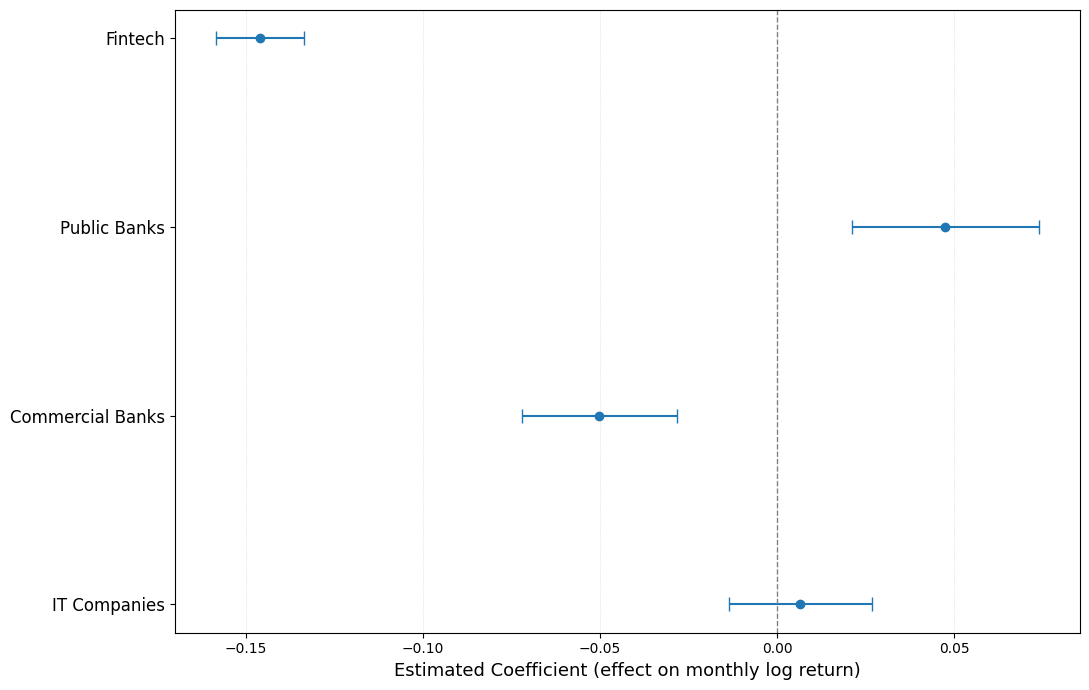

Saved: CBDC_effects_plot_no_stars.png


In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Load your results CSV
# -------------------------------
paths = [
    "cbdc_interaction_only_summary.csv",
    "cbdc_interaction_only_summary.csv"
]
csv_path = next((p for p in paths if os.path.exists(p)), paths[1])

df = pd.read_csv(csv_path)

# -------------------------------
# Map model terms to clean labels
# -------------------------------
label_map = {
    "CBDC_SENTIMENT:fintech": "Fintech",
    "CBDC_SENTIMENT:public_bank": "Public Banks",
    "CBDC_SENTIMENT:commercial_bank": "Commercial Banks",
    "CBDC_SENTIMENT:it_company": "IT Companies"
}

terms_order = [
    "CBDC_SENTIMENT:fintech",
    "CBDC_SENTIMENT:public_bank",
    "CBDC_SENTIMENT:commercial_bank",
    "CBDC_SENTIMENT:it_company"
]

df = df.set_index("term").reindex(terms_order).reset_index()

# Fix std err column
if "std_err" not in df.columns:
    for alt in ["std_error", "se", "std", "stderr"]:
        if alt in df.columns:
            df.rename(columns={alt: "std_err"}, inplace=True)

labels = [label_map[t] for t in df["term"]]
coefs = df["coef"].astype(float).values
ses = df["std_err"].astype(float).values

ci95 = 1.96 * ses
lower = coefs - ci95
upper = coefs + ci95

# -------------------------------
# Plotting (NO stars)
# -------------------------------
plt.figure(figsize=(11, 7))

y = np.arange(len(labels))

plt.errorbar(
    coefs, y,
    xerr=ci95,
    fmt='o',
    capsize=5,
    markersize=6,
    linestyle="None"
)

# zero line
plt.axvline(0, linestyle='--', color='gray', linewidth=1)

# light grid
plt.grid(axis='x', linestyle=':', linewidth=0.5, alpha=0.6)

plt.yticks(y, labels, fontsize=12)
plt.gca().invert_yaxis()

plt.xlabel("Estimated Coefficient (effect on monthly log return)", fontsize=13)

plt.tight_layout()

output_file = "CBDC_effects_plot_no_stars.png"
plt.savefig(output_file, dpi=200, bbox_inches="tight")

plt.show()

print("Saved:", output_file)
